# Probability Rules on Continuous Random Variables

Let $x$ and $y$ be two **continuous** random variables with joint probability density function $p(x, y)$.

The same four rules from discrete probability carry over, with sums replaced by integrals:

| Rule | Discrete | Continuous |
|---|---|---|
| **Sum (marginal)** | $p(x) = \sum_y p(x,y)$ | $p(x) = \int p(x,y)\,dy$ |
| **Product** | $p(x,y) = p(x\|y)\,p(y)$ | $p(x,y) = p(x\|y)\,p(y)$ |
| **Independence** | $p(x,y) = p(x)\,p(y)$ | $p(x,y) = p(x)\,p(y)$ |
| **Bayes** | $p(y\|x) = \frac{p(x\|y)\,p(y)}{p(x)}$ | $p(y\|x) = \frac{p(x\|y)\,p(y)}{\int p(x,y)\,dy}$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
from scipy.stats import multivariate_normal, norm
from scipy.integrate import dblquad, quad

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

## 1 · Joint Probability Density Function $p(x, y)$

If $x$ and $y$ are two continuous random variables, their **joint PDF** $p(x, y)$ describes their simultaneous behaviour.

$$\Pr[a \leq x \leq b,\; c \leq y \leq d] = \int_a^b \int_c^d p(x,y)\,dy\,dx$$

Properties:
- $p(x, y) \geq 0$ for all $(x, y)$
- $\int_{-\infty}^{\infty}\int_{-\infty}^{\infty} p(x,y)\,dy\,dx = 1$

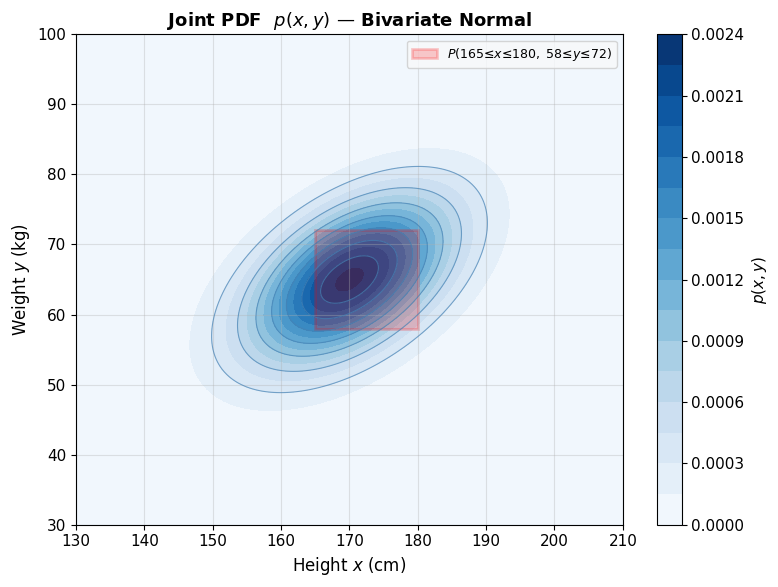

P(165≤x≤180, 58≤y≤72) ≈ 0.3574


In [2]:
# --- Joint PDF visualized as a 2-D Gaussian (heatmap + contours) ---
mu_x, mu_y   = 170, 65        # height (cm), weight (kg)
sig_x, sig_y = 10, 8
cov          = 40              # positive correlation

rv = multivariate_normal(mean=[mu_x, mu_y],
                         cov=[[sig_x**2, cov], [cov, sig_y**2]])

x_g = np.linspace(130, 210, 200)
y_g = np.linspace(30, 100, 200)
X, Y = np.meshgrid(x_g, y_g)
Z    = rv.pdf(np.dstack([X, Y]))

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(X, Y, Z, levels=20, cmap='Blues')
ax.contour(X, Y, Z, levels=8, colors='steelblue', linewidths=0.8, alpha=0.7)
plt.colorbar(cf, ax=ax, label='$p(x, y)$')

# shade a rectangular region to illustrate a joint probability
x1, x2, y1, y2 = 165, 180, 58, 72
ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  lw=2, edgecolor='red', facecolor='red', alpha=0.2,
                                  label=f'$P({x1}≤x≤{x2},\\ {y1}≤y≤{y2})$'))
prob_rect, _ = dblquad(lambda yv, xv: rv.pdf([xv, yv]),
                        x1, x2, y1, y2)
ax.set_xlabel('Height $x$ (cm)', fontsize=12)
ax.set_ylabel('Weight $y$ (kg)',  fontsize=12)
ax.set_title('Joint PDF  $p(x, y)$ — Bivariate Normal', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"P({x1}≤x≤{x2}, {y1}≤y≤{y2}) ≈ {prob_rect:.4f}")

## 2 · Sum Rule — Marginal Density Functions

The **marginal PDF** of $x$ is obtained by integrating the joint PDF over $y$:

$$\boxed{p(x) = \int_{-\infty}^{\infty} p(x,y)\; dy}$$

Similarly for $y$:

$$\boxed{p(y) = \int_{-\infty}^{\infty} p(x,y)\; dx}$$

Intuition: marginalizing "sums away" the variable we don't care about, collapsing the 2-D surface onto a 1-D curve.

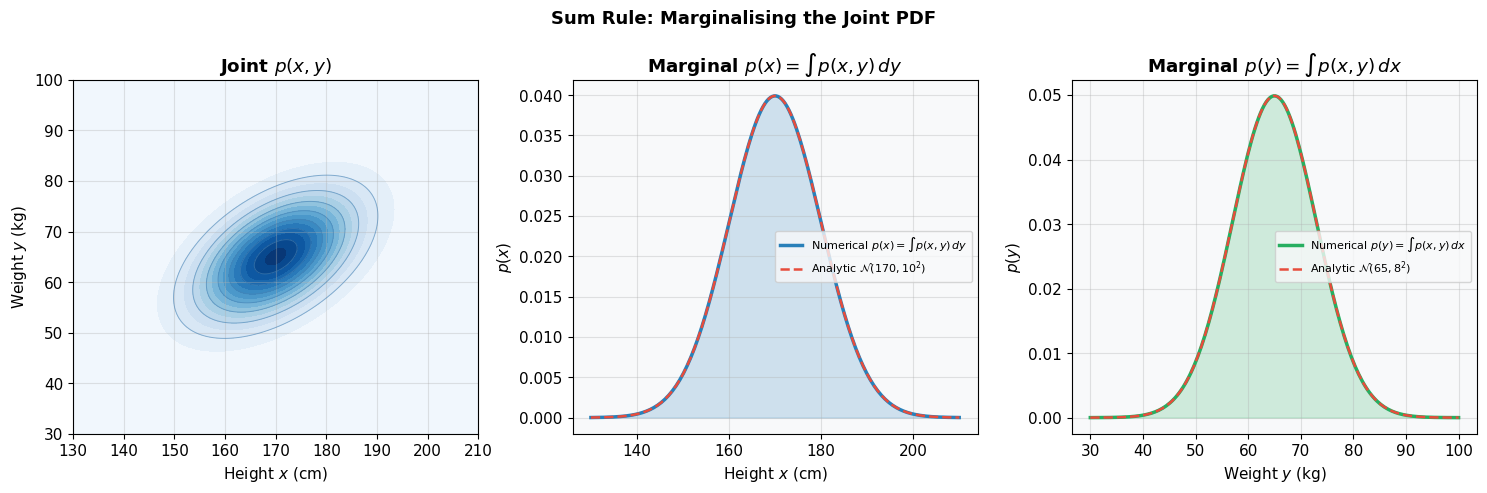

∫ p(x) dx ≈ 0.999926   (should be 1)
∫ p(y) dy ≈ 0.999930   (should be 1)


In [4]:
# --- Marginalisation: joint → marginal ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: joint PDF heatmap
ax = axes[0]
cf = ax.contourf(X, Y, Z, levels=20, cmap='Blues')
ax.contour(X, Y, Z, levels=8, colors='steelblue', linewidths=0.7, alpha=0.6)
ax.set_xlabel('Height $x$ (cm)'); ax.set_ylabel('Weight $y$ (kg)')
ax.set_title('Joint $p(x, y)$', fontweight='bold')

# Compute marginals numerically from the grid (dy = spacing)
dy = y_g[1] - y_g[0]
dx = x_g[1] - x_g[0]
p_x_marginal = Z.sum(axis=0) * dy   # integrate over y  → function of x
p_y_marginal = Z.sum(axis=1) * dx   # integrate over x  → function of y

# Also get analytic marginals (should be Normal)
p_x_analytic = norm.pdf(x_g, mu_x, sig_x)
p_y_analytic = norm.pdf(y_g, mu_y, sig_y)

# Panel 2: marginal of x
ax = axes[1]
ax.plot(x_g, p_x_marginal, color='#2980b9', lw=2.5, label='Numerical $p(x)=\\int p(x,y)\\,dy$')
ax.plot(x_g, p_x_analytic, color='#e74c3c', lw=1.8, ls='--', label='Analytic $\\mathcal{N}(170,10^2)$')
ax.fill_between(x_g, p_x_marginal, alpha=0.2, color='#2980b9')
ax.set_xlabel('Height $x$ (cm)'); ax.set_ylabel('$p(x)$')
ax.set_title('Marginal $p(x) = \\int p(x,y)\\,dy$', fontweight='bold')
ax.legend(fontsize=8)

# Panel 3: marginal of y
ax = axes[2]
ax.plot(y_g, p_y_marginal, color='#27ae60', lw=2.5, label='Numerical $p(y)=\\int p(x,y)\\,dx$')
ax.plot(y_g, p_y_analytic, color='#e74c3c', lw=1.8, ls='--', label='Analytic $\\mathcal{N}(65,8^2)$')
ax.fill_between(y_g, p_y_marginal, alpha=0.2, color='#27ae60')
ax.set_xlabel('Weight $y$ (kg)'); ax.set_ylabel('$p(y)$')
ax.set_title('Marginal $p(y) = \\int p(x,y)\\,dx$', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Sum Rule: Marginalising the Joint PDF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"∫ p(x) dx ≈ {np.trapezoid(p_x_marginal, x_g):.6f}   (should be 1)")
print(f"∫ p(y) dy ≈ {np.trapezoid(p_y_marginal, y_g):.6f}   (should be 1)")

## 3 · Product Rule

The joint PDF can always be factored into a **conditional** and a **marginal**:

$$\boxed{p(x, y) = p(x \mid y)\; p(y)}$$

$$\boxed{p(x, y) = p(y \mid x)\; p(x)}$$

Here $p(x \mid y)$ is the **conditional PDF** of $x$ given $y$ — it is the slice of the joint PDF at a fixed $y$, normalised so that it integrates to 1.

∫ p(x|y=65) dx ≈ 0.999996   (must be 1)


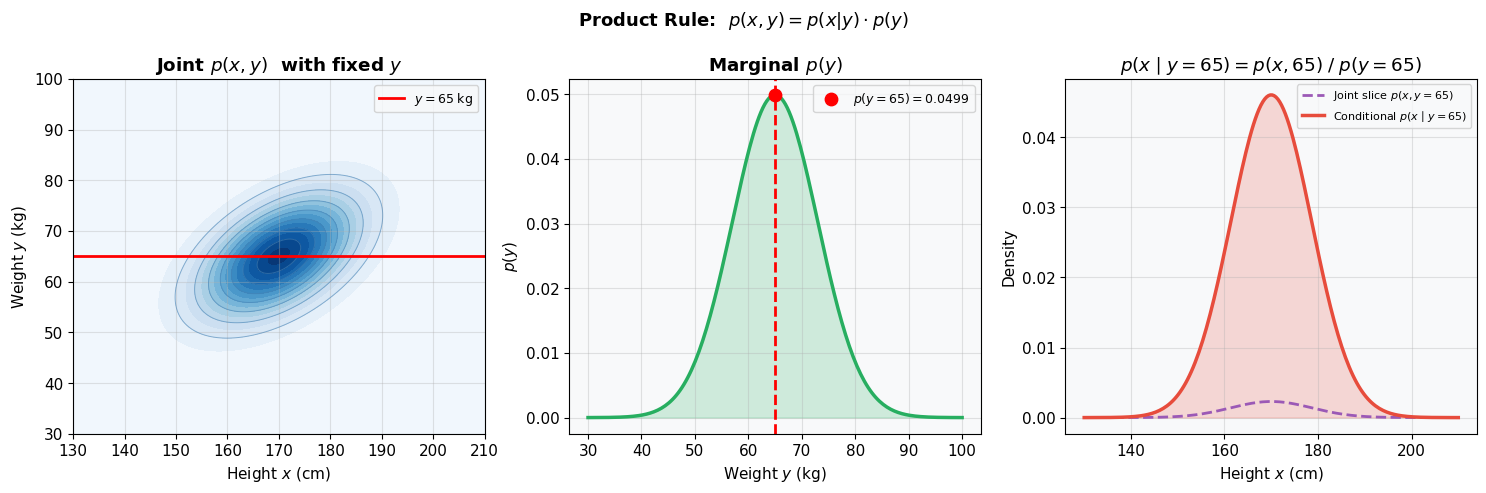

In [6]:
# --- Product rule: joint = conditional × marginal ---
# Fix y=65 kg and show the conditional slice p(x|y=65)

y_fixed = 65
# Joint slice at y=y_fixed
joint_slice = rv.pdf(np.column_stack([x_g, np.full_like(x_g, y_fixed)]))
# Marginal p(y=65)
p_y_fixed   = norm.pdf(y_fixed, mu_y, sig_y)
# Conditional p(x|y=65) = joint_slice / p(y=65)
cond_slice  = joint_slice / p_y_fixed

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: joint PDF with the fixed-y line
ax = axes[0]
ax.contourf(X, Y, Z, levels=20, cmap='Blues')
ax.contour(X, Y, Z, levels=8, colors='steelblue', linewidths=0.7, alpha=0.6)
ax.axhline(y_fixed, color='red', lw=2, label=f'$y = {y_fixed}$ kg')
ax.set_xlabel('Height $x$ (cm)'); ax.set_ylabel('Weight $y$ (kg)')
ax.set_title('Joint $p(x, y)$  with fixed $y$', fontweight='bold')
ax.legend(fontsize=9)

# Panel 2: marginal p(y)  — highlight the fixed value
ax = axes[1]
ax.plot(y_g, p_y_marginal, color='#27ae60', lw=2.5)
ax.fill_between(y_g, p_y_marginal, alpha=0.2, color='#27ae60')
ax.axvline(y_fixed, color='red', lw=2, ls='--')
ax.scatter([y_fixed], [p_y_fixed], s=80, zorder=5, color='red',
           label=f'$p(y={y_fixed})={p_y_fixed:.4f}$')
ax.set_xlabel('Weight $y$ (kg)'); ax.set_ylabel('$p(y)$')
ax.set_title('Marginal $p(y)$', fontweight='bold')
ax.legend(fontsize=9)

# Panel 3: conditional p(x|y=65)
ax = axes[2]
ax.plot(x_g, joint_slice, color='#9b59b6', lw=2,  ls='--',
        label=f'Joint slice $p(x, y={y_fixed})$')
ax.plot(x_g, cond_slice,  color='#e74c3c', lw=2.5,
        label=f'Conditional $p(x\\mid y={y_fixed})$')
ax.fill_between(x_g, cond_slice, alpha=0.2, color='#e74c3c')
ax.set_xlabel('Height $x$ (cm)'); ax.set_ylabel('Density')
ax.set_title(f'$p(x\\mid y={y_fixed}) = p(x,{y_fixed})\\;/\\;p(y={y_fixed})$', fontweight='bold')
ax.legend(fontsize=8)

print(f"∫ p(x|y={y_fixed}) dx ≈ {np.trapezoid(cond_slice, x_g):.6f}   (must be 1)")

plt.suptitle('Product Rule:  $p(x,y) = p(x|y)\\cdot p(y)$',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4 · Independence

$x$ and $y$ are **statistically independent** when knowing $y$ gives no information about $x$:

$$\boxed{p(x, y) = p(x)\; p(y)}$$

This means:
- The conditional equals the marginal: $p(x \mid y) = p(x)$
- The joint is exactly the outer product of the two marginals
- Contour lines of $p(x,y)$ are **axis-aligned ellipses** (no tilt)

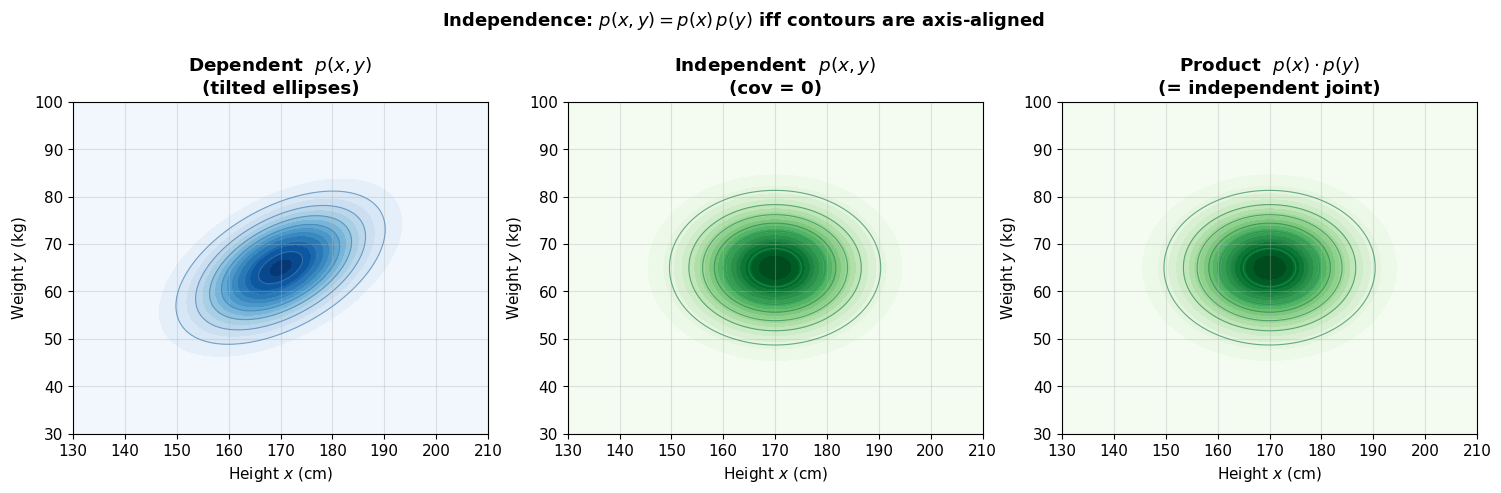

Max|p(x,y) – p(x)·p(y)| for independent case = 1.73e-18  (≈ 0 ✓)


In [7]:
# --- Independence: correlated vs independent joint PDF ---
rv_dep = multivariate_normal(mean=[mu_x, mu_y],
                              cov=[[sig_x**2, cov], [cov, sig_y**2]])   # correlated
rv_ind = multivariate_normal(mean=[mu_x, mu_y],
                              cov=[[sig_x**2, 0],   [0,   sig_y**2]])   # independent

Z_dep = rv_dep.pdf(np.dstack([X, Y]))
Z_ind = rv_ind.pdf(np.dstack([X, Y]))
# Product of marginals (should equal Z_ind)
Z_prod = norm.pdf(X, mu_x, sig_x) * norm.pdf(Y, mu_y, sig_y)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, Z_plot, title, check in zip(
    axes,
    [Z_dep, Z_ind, Z_prod],
    ['Dependent  $p(x,y)$\n(cov = 40)',
     'Independent  $p(x,y)$\n(cov = 0)',
     'Product  $p(x)\\cdot p(y)$\n(= independent joint)'],
    [False, True, True]
):
    ax.contourf(X, Y, Z_plot, levels=20, cmap='Greens' if check else 'Blues')
    cs = ax.contour(X, Y, Z_plot, levels=8,
                    colors='seagreen' if check else 'steelblue',
                    linewidths=0.8, alpha=0.7)
    ax.set_xlabel('Height $x$ (cm)'); ax.set_ylabel('Weight $y$ (kg)')
    ax.set_title(title, fontweight='bold')

axes[0].set_title('Dependent  $p(x,y)$\n(tilted ellipses)', fontweight='bold')
plt.suptitle('Independence: $p(x,y) = p(x)\\,p(y)$ iff contours are axis-aligned',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Verify: max absolute difference between independent joint and product
max_diff = np.abs(Z_ind - Z_prod).max()
print(f"Max|p(x,y) – p(x)·p(y)| for independent case = {max_diff:.2e}  (≈ 0 ✓)")

## 5 · Bayes Rule

Combining the **product rule** symmetry $p(x,y) = p(x \mid y)\,p(y) = p(y \mid x)\,p(x)$:

$$\boxed{p(y \mid x) = \frac{p(x \mid y)\; p(y)}{p(x)}}$$

The denominator $p(x)$ is obtained via the **sum rule** (total probability):

$$p(x) = \int p(x, y)\; dy = \int p(x \mid y)\; p(y)\; dy$$

So the full form is:

$$p(y \mid x) = \frac{p(x \mid y)\; p(y)}{\displaystyle\int p(x \mid y)\; p(y)\; dy}$$

Similarly:

$$p(x \mid y) = \frac{p(y \mid x)\; p(x)}{p(y)}$$

| Term | Name |
|---|---|
| $p(y \mid x)$ | **Posterior** — updated belief about $y$ after observing $x$ |
| $p(x \mid y)$ | **Likelihood** — how probable is $x$ if $y$ is true |
| $p(y)$ | **Prior** — belief about $y$ before observing $x$ |
| $p(x)$ | **Evidence** — normalisation constant |

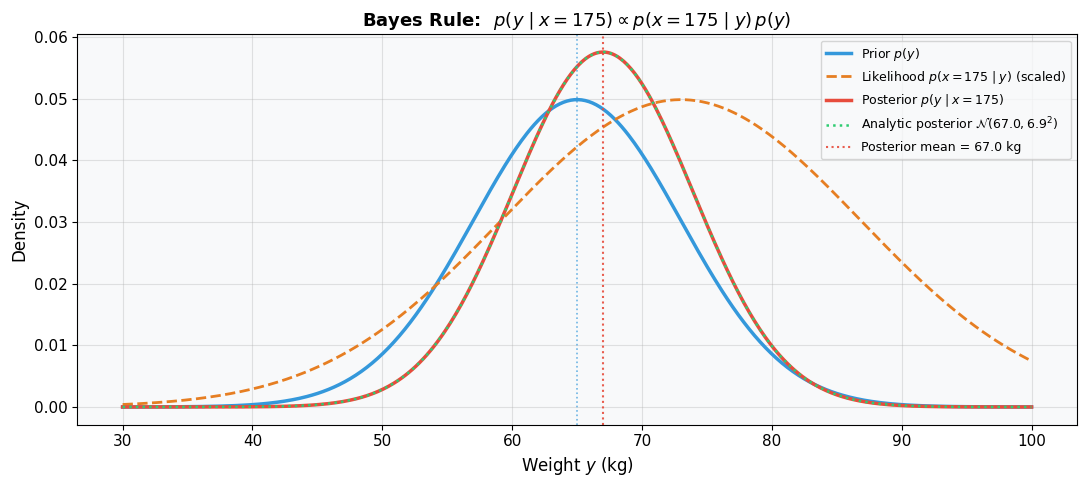

Prior mean            p(y):        μ = 65 kg
Observed height       x = 175 cm
Posterior mean        p(y|x=175): μ = 67.00 kg
Posterior std         p(y|x=175): σ = 6.93 kg
Evidence (normaliser) ≈ 0.035206


In [9]:
# --- Bayes rule: posterior = likelihood × prior / evidence ---
# Scenario: estimate weight y given observed height x=175 cm
# Prior:       p(y)         ~ N(65, 8^2)
# Likelihood:  p(x=175|y)  ~ N(mu_x + rho*(y - mu_y), sig_x^2*(1-rho^2))
#   where rho is the correlation coefficient from the joint distribution.

rho   = cov / (sig_x * sig_y)               # correlation coefficient

x_obs = 175                                  # observed height

# Conditional mean and std of x given y  (from bivariate normal theory)
# p(x | y) = N(mu_x + rho*(sig_x/sig_y)*(y - mu_y), sig_x^2*(1-rho^2))
cond_sig_x = sig_x * np.sqrt(1 - rho**2)

y_range = np.linspace(30, 100, 500)

prior      = norm.pdf(y_range, mu_y, sig_y)
likelihood = norm.pdf(x_obs,
                      mu_x + rho * (sig_x / sig_y) * (y_range - mu_y),
                      cond_sig_x)

unnorm_posterior = likelihood * prior
evidence         = np.trapezoid(unnorm_posterior, y_range)       # ∫ L·prior dy
posterior        = unnorm_posterior / evidence

# Analytic posterior (also Normal for conjugate Gaussian case)
post_mu  = mu_y + rho * (sig_y / sig_x) * (x_obs - mu_x)
post_sig = sig_y * np.sqrt(1 - rho**2)
post_analytic = norm.pdf(y_range, post_mu, post_sig)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(y_range, prior,         color='#3498db', lw=2.5, label='Prior $p(y)$')
ax.plot(y_range, likelihood/likelihood.max()*prior.max(),
        color='#e67e22', lw=2, ls='--',
        label=f'Likelihood $p(x={x_obs}\\mid y)$ (scaled)')
ax.plot(y_range, posterior,     color='#e74c3c', lw=2.5, label='Posterior $p(y\\mid x=175)$')
ax.plot(y_range, post_analytic, color='#2ecc71', lw=1.8, ls=':',
        label=f'Analytic posterior $\\mathcal{{N}}({post_mu:.1f}, {post_sig:.1f}^2)$')

ax.axvline(mu_y,    color='#3498db', lw=1.2, ls=':', alpha=0.7)
ax.axvline(post_mu, color='#e74c3c', lw=1.5, ls=':', alpha=0.9,
           label=f'Posterior mean = {post_mu:.1f} kg')

ax.set_xlabel('Weight $y$ (kg)', fontsize=12)
ax.set_ylabel('Density',         fontsize=12)
ax.set_title(f'Bayes Rule:  $p(y\\mid x={x_obs}) \\propto p(x={x_obs}\\mid y)\\,p(y)$',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Prior mean            p(y):        μ = {mu_y} kg")
print(f"Observed height       x = {x_obs} cm")
print(f"Posterior mean        p(y|x={x_obs}): μ = {post_mu:.2f} kg")
print(f"Posterior std         p(y|x={x_obs}): σ = {post_sig:.2f} kg")
print(f"Evidence (normaliser) ≈ {evidence:.6f}")

## Summary

| Rule | Formula | Key idea |
|---|---|---|
| **Joint PDF** | $p(x,y) \geq 0$, $\iint p(x,y)\,dx\,dy = 1$ | Full description of two RVs |
| **Sum rule** | $p(x) = \int p(x,y)\,dy$ | Marginalise out $y$ |
| **Product rule** | $p(x,y) = p(x\mid y)\,p(y) = p(y\mid x)\,p(x)$ | Factor joint into conditional × marginal |
| **Independence** | $p(x,y) = p(x)\,p(y)$ | Conditional = marginal: $p(x\mid y)=p(x)$ |
| **Bayes rule** | $p(y\mid x) = \dfrac{p(x\mid y)\,p(y)}{\int p(x\mid y)\,p(y)\,dy}$ | Invert the conditional |

## PDF vs CDF — How the Rules Change

The key bridge between the two:

$$p(x) = \frac{dF(x)}{dx} \qquad F(x) = \int_{-\infty}^{x} p(t)\,dt$$

$$p(x,y) = \frac{\partial^2 F(x,y)}{\partial x\,\partial y} \qquad F(x,y) = \int_{-\infty}^{x}\int_{-\infty}^{y} p(u,v)\,dv\,du$$

| Rule | In terms of PDF | In terms of CDF |
|---|---|---|
| **Joint** | $p(x,y) \geq 0$, $\iint p = 1$ | $F(x,y) \in [0,1]$, $F(\infty,\infty)=1$ |
| **Marginal** | $p(x) = \int p(x,y)\,dy$ | $F_X(x) = F(x,+\infty)$ |
| **Conditional** | $p(x\mid y) = \dfrac{p(x,y)}{p(y)}$ | $F_{X\mid Y}(x\mid y) = \int_{-\infty}^{x} \dfrac{p(u,y)}{p(y)}\,du$ |
| **Independence** | $p(x,y) = p(x)\,p(y)$ | $F(x,y) = F_X(x)\cdot F_Y(y)$ |
| **Bayes** | $p(y\mid x) = \dfrac{p(x\mid y)\,p(y)}{p(x)}$ | Same form; $p(x) = \dfrac{dF_X(x)}{dx}$ |

> **Key insight**: Independence is the cleanest rule to check with CDFs — if the joint CDF factors into a product of marginal CDFs, the variables are independent.

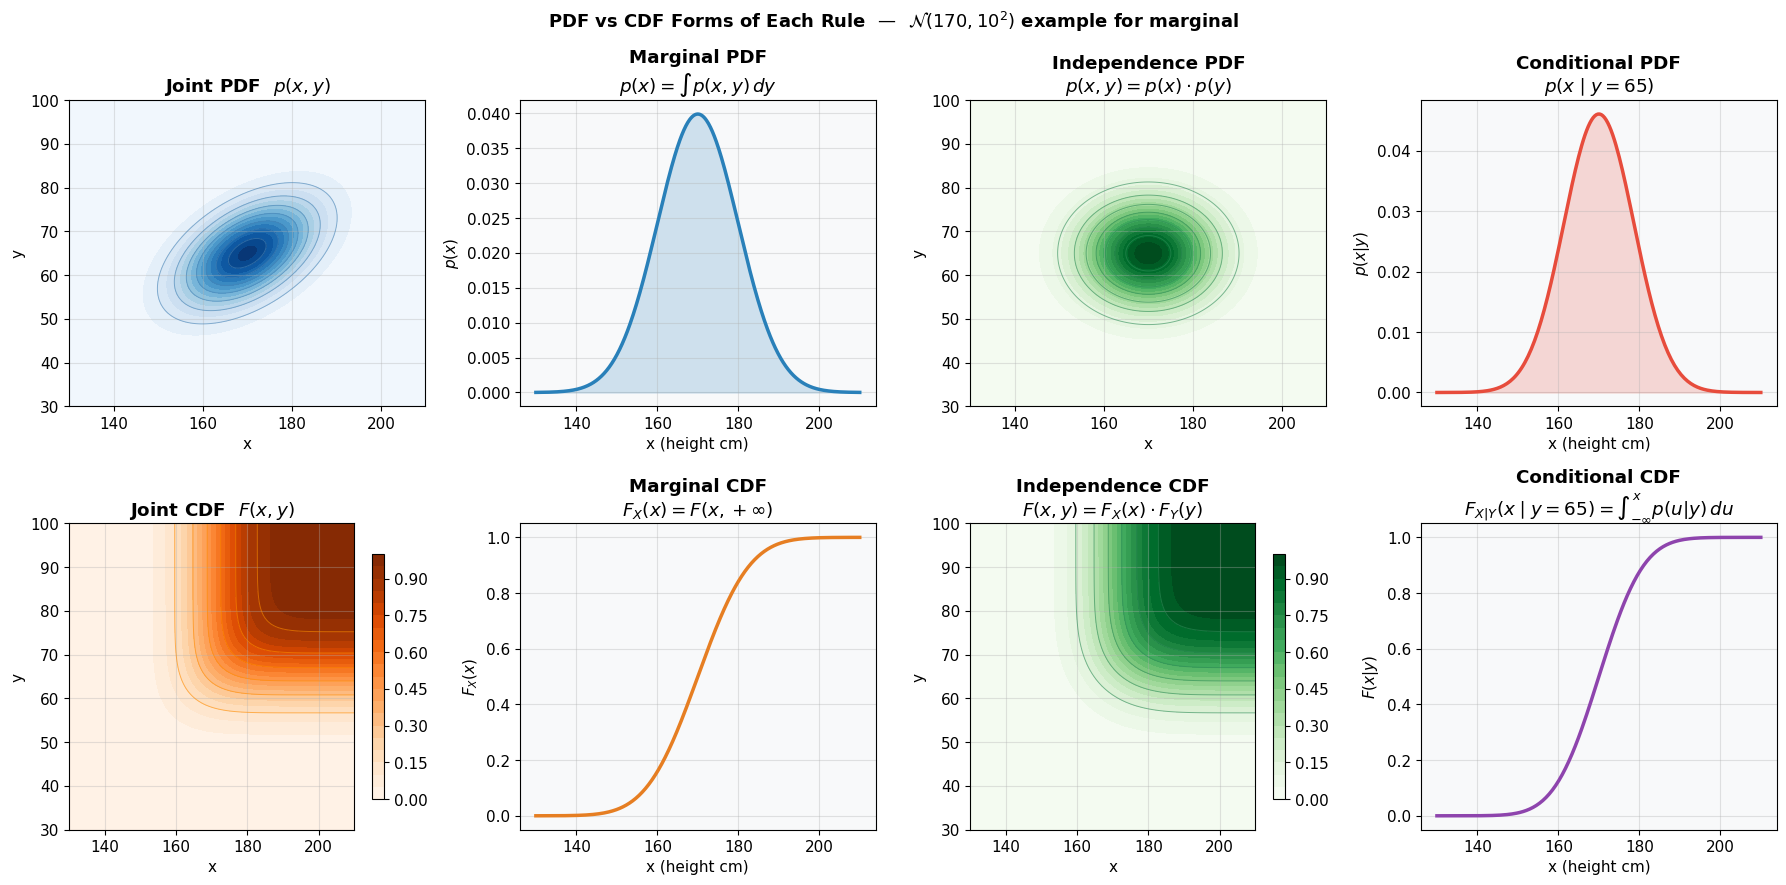

Max|F_ind(x,y) - F_X(x)·F_Y(y)| = 3.33e-16  (≈ 0 ✓)


In [11]:
# --- PDF vs CDF side-by-side for all four rules ---
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('PDF vs CDF Forms of Each Rule  —  $\\mathcal{N}(170,10^2)$ example for marginal',
             fontsize=13, fontweight='bold')

x_1d = np.linspace(130, 210, 500)
pdf_1d = norm.pdf(x_1d, mu_x, sig_x)
cdf_1d = norm.cdf(x_1d, mu_x, sig_x)

# ── Column 0: Joint ─────────────────────────────────────────────────────────
axes[0, 0].contourf(X, Y, Z, levels=20, cmap='Blues')
axes[0, 0].contour(X, Y, Z,  levels=8,  colors='steelblue', linewidths=0.7, alpha=0.6)
axes[0, 0].set_title('Joint PDF  $p(x,y)$', fontweight='bold')
axes[0, 0].set_xlabel('x'); axes[0, 0].set_ylabel('y')

F_joint = rv.cdf(np.dstack([X, Y]))
cf2 = axes[1, 0].contourf(X, Y, F_joint, levels=20, cmap='Oranges')
axes[1, 0].contour(X, Y, F_joint, levels=8, colors='darkorange', linewidths=0.7, alpha=0.6)
plt.colorbar(cf2, ax=axes[1, 0], shrink=0.8)
axes[1, 0].set_title('Joint CDF  $F(x,y)$', fontweight='bold')
axes[1, 0].set_xlabel('x'); axes[1, 0].set_ylabel('y')

# ── Column 1: Marginal ───────────────────────────────────────────────────────
axes[0, 1].plot(x_1d, pdf_1d, color='#2980b9', lw=2.5)
axes[0, 1].fill_between(x_1d, pdf_1d, alpha=0.2, color='#2980b9')
axes[0, 1].set_title('Marginal PDF\n$p(x)=\\int p(x,y)\\,dy$', fontweight='bold')
axes[0, 1].set_xlabel('x (height cm)'); axes[0, 1].set_ylabel('$p(x)$')

axes[1, 1].plot(x_1d, cdf_1d, color='#e67e22', lw=2.5)
axes[1, 1].set_title('Marginal CDF\n$F_X(x)=F(x,+\\infty)$', fontweight='bold')
axes[1, 1].set_xlabel('x (height cm)'); axes[1, 1].set_ylabel('$F_X(x)$')
axes[1, 1].set_ylim(-0.05, 1.05)

# ── Column 2: Independence ───────────────────────────────────────────────────
axes[0, 2].contourf(X, Y, Z_ind, levels=20, cmap='Greens')
axes[0, 2].contour(X, Y, Z_ind, levels=8, colors='seagreen', linewidths=0.7, alpha=0.6)
axes[0, 2].set_title('Independence PDF\n$p(x,y)=p(x)\\cdot p(y)$', fontweight='bold')
axes[0, 2].set_xlabel('x'); axes[0, 2].set_ylabel('y')

F_X_grid = norm.cdf(X, mu_x, sig_x)
F_Y_grid = norm.cdf(Y, mu_y, sig_y)
F_ind    = F_X_grid * F_Y_grid
cf3 = axes[1, 2].contourf(X, Y, F_ind, levels=20, cmap='Greens')
axes[1, 2].contour(X, Y, F_ind, levels=8, colors='seagreen', linewidths=0.7, alpha=0.6)
plt.colorbar(cf3, ax=axes[1, 2], shrink=0.8)
axes[1, 2].set_title('Independence CDF\n$F(x,y)=F_X(x)\\cdot F_Y(y)$', fontweight='bold')
axes[1, 2].set_xlabel('x'); axes[1, 2].set_ylabel('y')

# ── Column 3: Conditional (use x_g — same grid as cond_slice) ────────────────
# cond_slice was computed on x_g (200 pts) in the product-rule cell
cond_mu  = mu_x + rho * (sig_x / sig_y) * (y_fixed - mu_y)
cond_sig = sig_x * np.sqrt(1 - rho**2)

axes[0, 3].plot(x_g, cond_slice, color='#e74c3c', lw=2.5)
axes[0, 3].fill_between(x_g, cond_slice, alpha=0.2, color='#e74c3c')
axes[0, 3].set_title(f'Conditional PDF\n$p(x\\mid y={y_fixed})$', fontweight='bold')
axes[0, 3].set_xlabel('x (height cm)'); axes[0, 3].set_ylabel('$p(x|y)$')

cond_cdf = norm.cdf(x_g, cond_mu, cond_sig)
axes[1, 3].plot(x_g, cond_cdf, color='#8e44ad', lw=2.5)
axes[1, 3].set_ylim(-0.05, 1.05)
axes[1, 3].set_title(f'Conditional CDF\n$F_{{X|Y}}(x\\mid y={y_fixed})=\\int_{{-\\infty}}^x p(u|y)\\,du$',
                     fontweight='bold')
axes[1, 3].set_xlabel('x (height cm)'); axes[1, 3].set_ylabel('$F(x|y)$')

plt.tight_layout()
plt.show()

# Verify independence: max|F_joint_indep - F_X·F_Y|
F_ind_rv = rv_ind.cdf(np.dstack([X, Y]))
print(f"Max|F_ind(x,y) - F_X(x)·F_Y(y)| = {np.abs(F_ind_rv - F_ind).max():.2e}  (≈ 0 ✓)")